In [117]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

environment

In [118]:
# environment part taken from https://github.com/LyWangPX/Reinforcement-Learning-2nd-Edition-by-Sutton-Exercise-Solutions/blob/master/Chapter%206/Ex6.9.ipynb

class WindyGridworld():
    def __init__(self, is_eight_action = False, ninth_action = False):
        # origin is defined as left_lower corner. and start from 1
        # namely cols are : 1 2 3 4 5 6 7 8 9 10
        # rows are : 1 2 3 4 5 6 7
        # we start from (1, 4)
        self.xlimit = 10
        self.ylimit = 7
        self.is_eight_action = is_eight_action
        self.ninth_action = ninth_action
        # we use explicit dictionary instead of function to accelerate training
        self.wind_dict = { 1: 0, 2: 0, 3: 0, 4: 1, 5: 1,
                           6: 1, 7: 2, 8: 2, 9: 1, 10: 0 }

    def step(self, pos, action):
        x, y = pos
        wind = self.wind_dict[x]
        if action == 'left':
            next_state = max(1, x-1), min(y+wind, self.ylimit)
        elif action == 'right':
            next_state = min(self.xlimit, x+1), min(y+wind, self.ylimit)
        elif action == 'up':
            next_state = x, min(y+wind+1, self.ylimit)
        elif action == 'down':
            next_state = x, max(0, min(y+wind-1, self.ylimit))
        else:
            if self.is_eight_action:
                if action == 'left-up':
                    next_state = max(1, x-1), min(y+wind+1, self.ylimit)
                elif action == 'left-down':
                    next_state = max(1, x-1), max(0,min(y+wind-1, self.ylimit))
                elif action == 'right-up':
                    next_state = min(self.xlimit, x+1), min(y+wind+1, self.ylimit)
                elif action == 'right-down':
                    next_state = min(self.xlimit, x+1), max(0,min(y+wind-1, self.ylimit))
                else:
                    if self.ninth_action:
                        if action == 'stay':
                            next_state = x, max(0,min(y+wind, self.ylimit))
                        else:
                            raise ValueError
                    else:
                        raise ValueError
            else:
                raise ValueError
        if next_state == (8, 4):
            return next_state, 0
        else:
            return next_state, -1

In [119]:
agent = WindyGridworld()
init_state = (1,4)
state = init_state

action = 'left'
outcome = agent.step(state, action)
state_next = outcome[0]
reward = outcome[1]

sarsa on policy

In [120]:
def train( episodes = 200,
    max_steps = 5000,
    alpha = 0.5,
    gamma = 1,
    epsilon = 0.1):
    #init Q(s,a) for all s in S, for all a in A arbitrarily, init Q(terminal) = 0
    agent = WindyGridworld()
    START = (1, 4)
    GOAL = (8, 4)

    def to_idx(state):
        x, y = state
        return x - 1, y - 1

    #along dim 3, 0 = up, 1 = left, 2 = down, 3 = right
    state_to_action = {
        0: 'up',
        1: 'left',
        2: 'down',
        3: 'right'
    }

    q = np.random.rand(agent.xlimit, agent.ylimit, 4)
    # q = np.zeros((agent.xlimit, agent.ylimit, 4))

    gx, gy = to_idx(GOAL)
    q[gx, gy, :] = 0


    def eps_greedy(q_vals, epsilon):
        if np.random.rand() < epsilon:
            return np.random.randint(len(q_vals))
        return np.argmax(q_vals)

    steps_needed_finish = []
    for i in range(episodes):
        #init S
        state = START
        xi, yi = to_idx(state)

        #choose A from S using eps-greedy Q
        action_raw = eps_greedy(q[xi, yi, :], epsilon)

        #for step in episode - eps greedy step
        for j in range(max_steps):
            #take A, observe R, S'
            action = state_to_action[action_raw]
            state_next, reward = agent.step(state, action)
            xni, yni = to_idx(state_next)

            if state_next == GOAL:
                q[xi, yi, action_raw] += alpha * (reward - q[xi, yi, action_raw])
                steps_needed_finish.append(j + 1)
                break

            #choose A' from S' using eps-greedy Q
            action_next_raw = eps_greedy(q[xni, yni, :], epsilon)

            #update: Q(s, a) <- Q(s, a) + alpha[R + gamma Q(s', a') - Q(s,a)]
            q[xi, yi, action_raw] += alpha * (
                reward + gamma * q[xni, yni, action_next_raw] - q[xi, yi, action_raw]
            )

            #S<-S', A<-A'
            state = state_next
            xi, yi = xni, yni
            action_raw = action_next_raw

    return steps_needed_finish

plotting different gammas

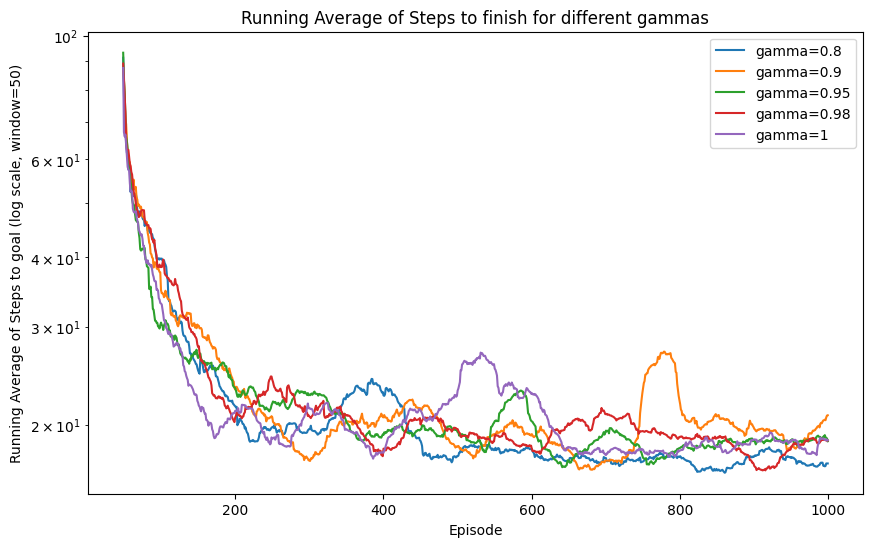

In [121]:
gammas = [0.8, 0.9, 0.95, 0.98, 1]
results = []

def running_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window_size = 50  # You can adjust this window size as needed

for gamma in gammas:
    steps_needed = train(gamma=gamma, episodes = 1000)
    results.append(steps_needed)

# Plotting running averages
plt.figure(figsize=(10,6))
for idx, gamma in enumerate(gammas):
    avg_steps = running_average(results[idx], window_size=window_size)
    plt.semilogy(
        range(window_size-1, len(results[idx])), 
        avg_steps, 
        label=f'gamma={gamma}'
    )
plt.xlabel('Episode')
plt.ylabel(f'Running Average of Steps to goal (log scale, window={window_size})')
plt.title('Running Average of Steps to finish for different gammas')
plt.legend()
plt.show()
